In [1]:
import sys
sys.dont_write_bytecode = True
%load_ext autoreload
%autoreload 1
%aimport classify_dice
import classify_dice
from ultralytics import YOLO
import sklearn
import cv2
from matplotlib import pyplot as plt
import numpy as np
import einops

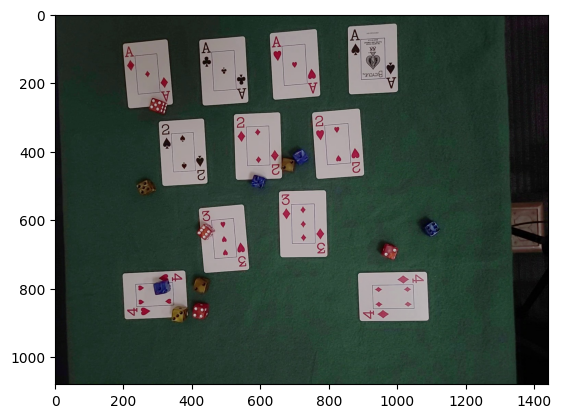

In [2]:
obb_model = YOLO("model/rdg_obb/weights/best.pt")
obb_model = YOLO("model/rdg_obb6/weights/best.pt")

example_frame = "data/frames/frame_0214.jpg"
# example_frame = "data/additional_photos/raw/20251208_171417.jpg"
# example_frame = "data/additional_photos/raw/20251208_182235.jpg"
img = cv2.imread(example_frame)
classify_dice.imshow(img)

In [3]:
res = obb_model(img, task='obb')[0]
res


0: 384x512 11 dies, 4 aces, 3 twos, 2 threes, 2 fours, 52.6ms
Speed: 14.0ms preprocess, 52.6ms inference, 156.2ms postprocess per image at shape (1, 3, 384, 512)


ultralytics.engine.results.Results object with attributes:

boxes: None
keypoints: None
masks: None
names: {0: 'die', 1: 'ace', 2: 'two', 3: 'three', 4: 'four'}
obb: ultralytics.engine.results.OBB object
orig_img: array([[[20, 25, 23],
        [21, 26, 24],
        [29, 33, 28],
        ...,
        [33, 26, 31],
        [28, 21, 24],
        [21, 14, 17]],

       [[18, 23, 21],
        [19, 24, 22],
        [28, 32, 27],
        ...,
        [32, 25, 30],
        [28, 21, 24],
        [23, 16, 19]],

       [[17, 22, 20],
        [17, 22, 20],
        [27, 31, 26],
        ...,
        [30, 23, 28],
        [27, 20, 25],
        [24, 17, 22]],

       ...,

       [[11, 11, 11],
        [11, 11, 11],
        [11, 11, 11],
        ...,
        [ 2,  2,  2],
        [ 2,  2,  2],
        [ 2,  2,  2]],

       [[11, 11, 11],
        [11, 11, 11],
        [11, 11, 11],
        ...,
        [ 2,  2,  2],
        [ 2,  2,  2],
        [ 2,  2,  2]],

       [[11, 11, 11],
        [11, 11,

In [4]:
res[0].obb

ultralytics.engine.results.OBB object with attributes:

cls: tensor([2.], device='cuda:0')
conf: tensor([0.9483], device='cuda:0')
data: tensor([[828.0497, 376.9739, 204.7811, 145.3723,   1.4911,   0.9483,   2.0000]], device='cuda:0')
id: None
is_track: False
orig_shape: (1080, 1440)
shape: torch.Size([1, 7])
xywhr: tensor([[828.0497, 376.9739, 204.7811, 145.3723,   1.4911]], device='cuda:0')
xyxy: tensor([[747.4457, 269.1237, 908.6537, 484.8242]], device='cuda:0')
xyxyxyxy: tensor([[[763.7424, 484.8242],
         [908.6537, 473.2552],
         [892.3569, 269.1237],
         [747.4457, 280.6926]]], device='cuda:0')
xyxyxyxyn: tensor([[[0.5304, 0.4489],
         [0.6310, 0.4382],
         [0.6197, 0.2492],
         [0.5191, 0.2599]]], device='cuda:0')

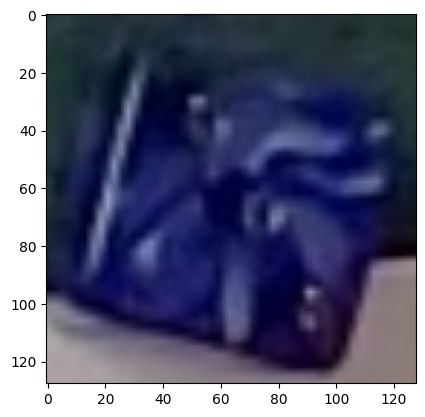

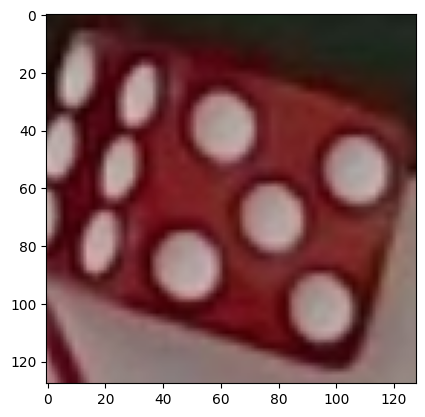

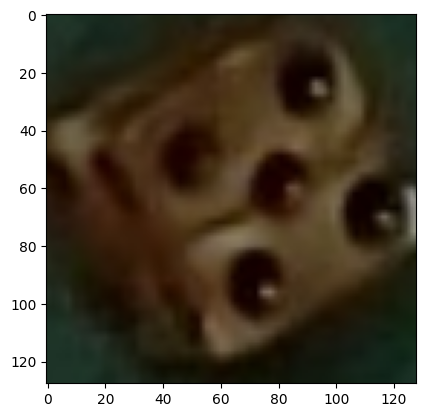

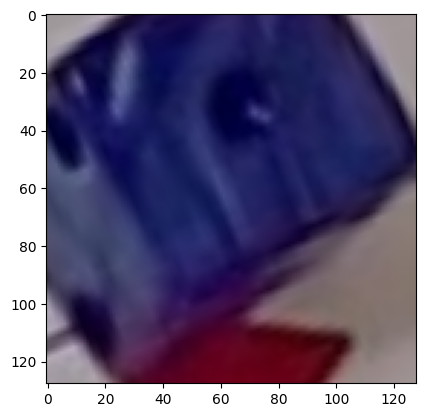

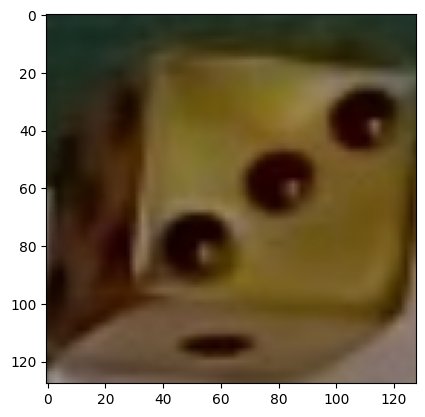

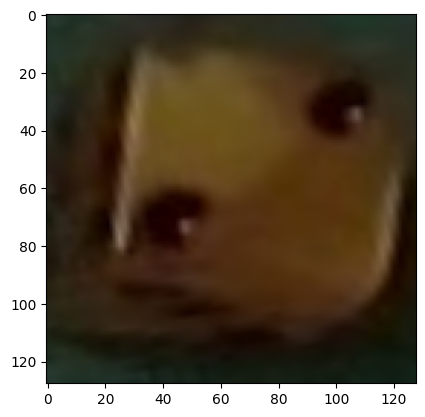

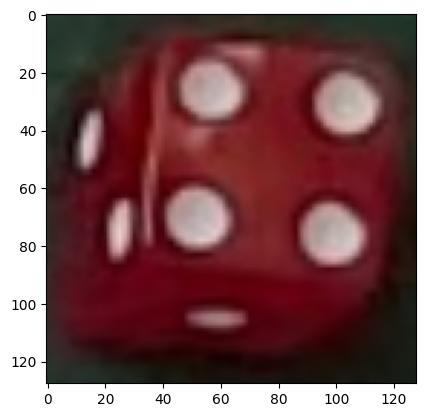

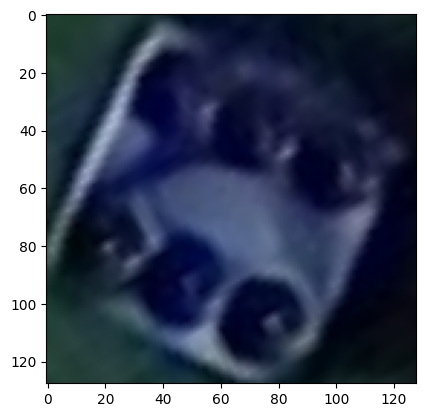

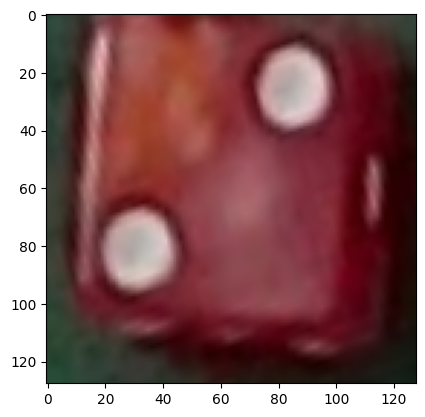

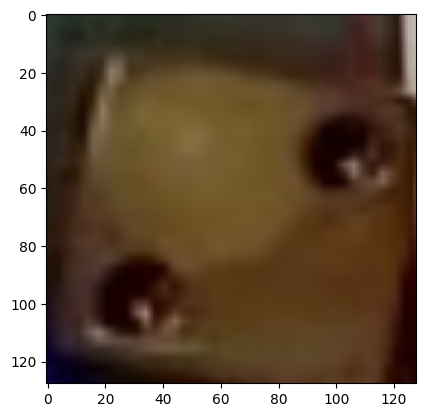

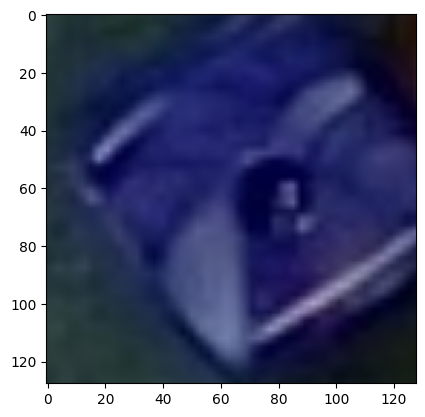

In [5]:
dice_cropped = classify_dice.batch_crop_dice(img, res)

for die_idx in range(dice_cropped.shape[0]):
    plt.figure()
    classify_dice.imshow(dice_cropped[die_idx,:,:,:])

In [6]:
k_means,palette = classify_dice.kmeans_color(dice_cropped, k=16)

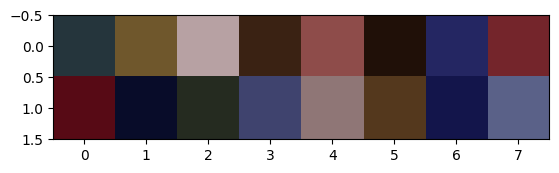

In [7]:
classify_dice.imshow(einops.rearrange(palette, "(h w) C -> h w C", w=8))

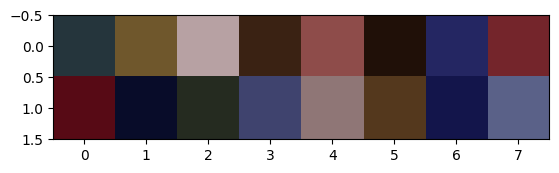

In [8]:
classify_dice.imshow(einops.rearrange(palette, "(h w) C -> h w C", w=8))

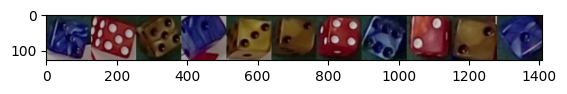

In [9]:
classify_dice.imshow(einops.rearrange(dice_cropped, "N H W C-> H (N W) C"))

<Figure size 640x480 with 0 Axes>

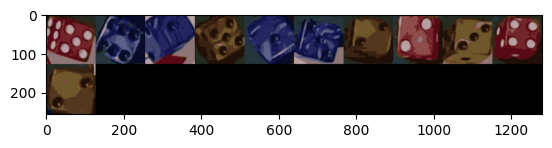

(973, 128, 128, 3)


<Figure size 640x480 with 0 Axes>

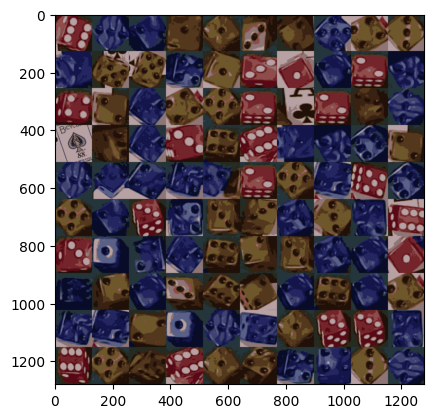

In [10]:
# recolor dice using this limited palette


classes,posterized = classify_dice.posterize(dice_cropped, k_means, palette)
sample_idxs = np.random.permutation(posterized.shape[0])[:100]
plt.figure()
# classify_dice.imshow(einops.rearrange(posterized[sample_idxs,...], "(N x) H W C -> (N H) (x W) C", x=4))
classify_dice.show_imgs_grid(posterized[sample_idxs,...], width=10)
plt.show()

# all_dice = classify_dice.generate_dice_dataset(obb_model)
all_dice = np.load('data/dice/all_dice.npz')['arr_0']
print(all_dice.shape)
_,all_dice_posterized = classify_dice.posterize(all_dice, k_means, palette)
sample_idxs = np.random.permutation(all_dice_posterized.shape[0])[:100]
plt.figure()
classify_dice.show_imgs_grid(all_dice_posterized[sample_idxs,...], width=10)
plt.show()


In [11]:
limgs,lids,lplayers,lvalues = classify_dice.load_labeled_dice()

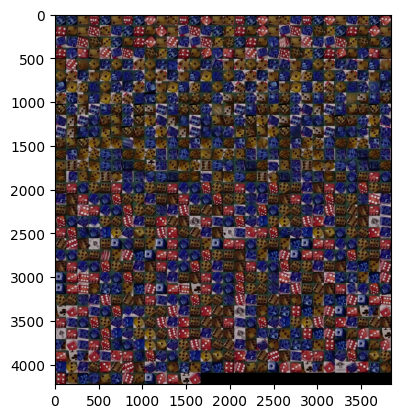

In [12]:
classify_dice.show_imgs_grid(all_dice,width=30)

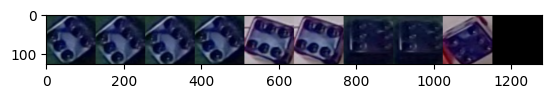

In [13]:
mask=(lplayers==2)&(lvalues==6)
classify_dice.show_imgs_grid(limgs[mask], width=10)

lids[bad_idx]=np.int64(938)


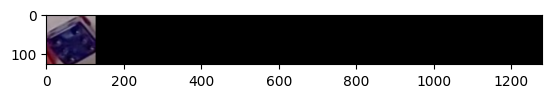

In [14]:
bad_idx = np.argwhere(np.cumsum(mask)==9)[0,0]
print(f"{lids[bad_idx]=}")
classify_dice.show_imgs_grid(limgs[[bad_idx],:,:,:])

np.int64(760)

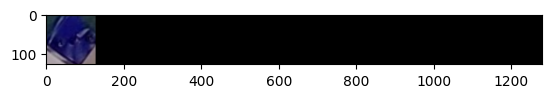

In [15]:
classify_dice.show_imgs_grid(limgs[[154],:,:,:])
lids[154]

In [16]:
# np.savez_compressed('data/dice/all_dice.npz', all_dice.astype(np.uint8))

In [17]:
# classify_dice.write_dice()

In [18]:
# def to_histogram(imgs):
#     N,H,W,C = imgs
classes,posterized = classify_dice.posterize(limgs, k_means, palette)


In [19]:
flattened_classes = einops.rearrange(classes, "N H W -> N (H W)")

histograms = np.zeros((flattened_classes.shape[0], palette.shape[0]))
for i in range(flattened_classes.shape[0]):
    histograms[i,:] = np.bincount(flattened_classes[i,:], minlength=palette.shape[0])
    histograms[i,:] /= histograms[i,:].sum()
# einops.reduce()
# np.bincount(flattened_classes, minlength=16)

# sklearn.d

histograms


array([[   0.033081,   0.0065308,     0.14465, ...,    0.046875,           0,           0],
       [   0.046875,     0.29681,           0, ...,     0.37421,           0,           0],
       [   0.024475,   0.0063477,     0.13342, ...,    0.050293,           0,           0],
       ...,
       [ 0.00067139,   0.0014038,     0.16138, ...,   0.0056152,           0,           0],
       [  0.0078735,     0.13458,   0.0011597, ...,     0.46252,   0.0022583,           0],
       [  0.0048828,   0.0014648,     0.16284, ...,   0.0042114,    0.022278,   0.0013428]], shape=(186, 16))

In [20]:
pca = sklearn.decomposition.PCA(n_components=2, whiten=True, random_state=1337)
hist_pca = pca.fit_transform(histograms)


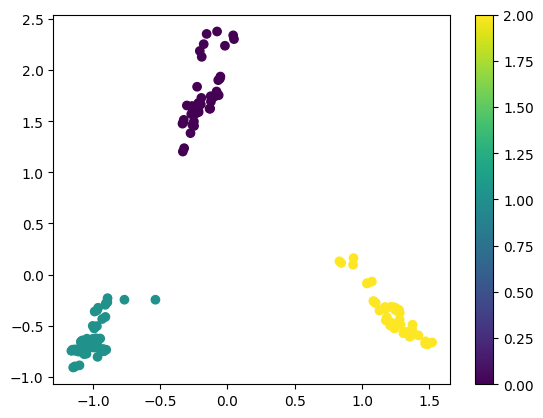

In [21]:
plt.scatter(hist_pca[:,0], hist_pca[:,1], c=lplayers)
plt.colorbar()

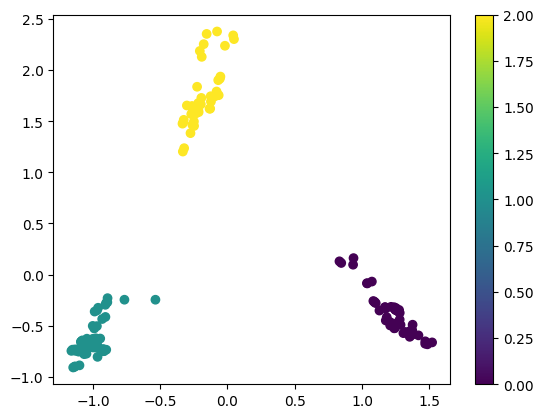

In [22]:
cluster_predictions = classify_dice.kmeans_cluster_players(histograms, n_players=3)
plt.scatter(hist_pca[:,0], hist_pca[:,1], c=cluster_predictions)
plt.colorbar()

pst.shape=(1, 1080, 1440, 3)


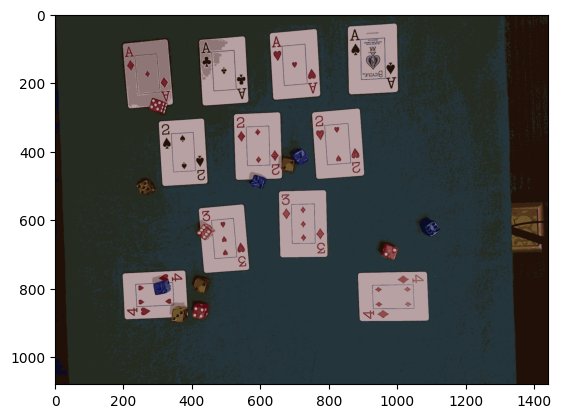

In [23]:
# classify_dice.imshow(classify_dice.posterize(img[None,:,:,:], k_means, palette))
# classify_dice.imshow()

_,pst = classify_dice.posterize(img[None,:,:,:], k_means, palette)
print(f"{pst.shape=}")
classify_dice.imshow(pst[0,:,:,:])


[[    0.98734    -0.43327]
 [    -1.2159       -1.21]
 [    0.12927      1.6969]
 [    -1.0307    -0.67357]
 [   -0.14179      1.9411]
 [    -1.2987    -0.70933]
 [     1.3344    -0.49055]
 [  -0.092504      3.5774]
 [  -0.030163       2.109]
 [     1.6332    -0.77663]
 [   -0.54163   -0.091519]
 [    0.76501    -0.13663]
 [    0.06611     0.88659]
 [    -1.4522     -1.0977]
 [     1.8678    -0.81464]
 [    0.55619   0.0015884]]


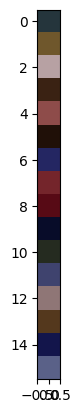

In [24]:
print(pca.transform(np.eye(16)))
classify_dice.imshow(einops.rearrange(palette, "N C -> N 1 C"))

In [25]:
for idx in range(10):
    print(idx)
    cap = cv2.VideoCapture(idx)
    if cap.isOpened():
        print(idx, 'open')
    cap.release()
cv2.destroyAllWindows()

cap = cv2.VideoCapture(2)
img = cap.read()[1]
cap.release()
classify_dice.imshow(res[1])
# res[1]

0
1
2
3
4
5
6
7
8
9


[ WARN:0@29.884] global cap_v4l.cpp:914 open VIDEOIO(V4L2:/dev/video0): can't open camera by index
[ERROR:0@29.889] global obsensor_uvc_stream_channel.cpp:163 getStreamChannelGroup Camera index out of range
[ WARN:0@29.891] global cap_v4l.cpp:914 open VIDEOIO(V4L2:/dev/video1): can't open camera by index
[ERROR:0@29.891] global obsensor_uvc_stream_channel.cpp:163 getStreamChannelGroup Camera index out of range
[ WARN:0@29.891] global cap_v4l.cpp:914 open VIDEOIO(V4L2:/dev/video2): can't open camera by index
[ERROR:0@29.891] global obsensor_uvc_stream_channel.cpp:163 getStreamChannelGroup Camera index out of range
[ WARN:0@29.891] global cap_v4l.cpp:914 open VIDEOIO(V4L2:/dev/video3): can't open camera by index
[ERROR:0@29.891] global obsensor_uvc_stream_channel.cpp:163 getStreamChannelGroup Camera index out of range
[ WARN:0@29.891] global cap_v4l.cpp:914 open VIDEOIO(V4L2:/dev/video4): can't open camera by index
[ERROR:0@29.891] global obsensor_uvc_stream_channel.cpp:163 getStreamChan

error: OpenCV(4.12.0) :-1: error: (-5:Bad argument) in function 'cvtColor'
> Overload resolution failed:
>  - src is not a numpy array, neither a scalar
>  - Expected Ptr<cv::UMat> for argument 'src'


In [ ]:
img_all = cv2.imread("data/misc/all.jpg")[None,:,:,:]
img_colors = [
    cv2.imread("data/misc/red.jpg")[None,:,:,:],
    cv2.imread("data/misc/yellow.jpg")[None,:,:,:],
    cv2.imread("data/misc/purple.jpg")[None,:,:,:],
]

In [27]:
classify_dice.fit_player_colors(obb_model, img_all, img_colors)

ValueError: not enough values to unpack (expected 4, got 3)